# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [16]:
# imports

import os
import json
import base64
from io import BytesIO
from dotenv import load_dotenv
from groq import Groq
import gradio as gr
import sqlite3
import requests
from PIL import Image
from huggingface_hub import InferenceClient

In [17]:
# Initialization

load_dotenv(override=True)

groq_api_key = os.getenv('GROQ_API_KEY')
hf_api_token = os.getenv('HUGGINGFACE_API_KEY')

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:8]}")
else:
    print("Groq API Key not set")
    
if hf_api_token:
    print(f"Hugging Face API Token exists and begins {hf_api_token[:8]}")
else:
    print("Hugging Face API Token not set")
    
# Use GPT-OSS-120B which supports tool calling
MODEL = "openai/gpt-oss-120b"
groq_client = Groq()

# Initialize Hugging Face client for image generation and TTS
hf_client = InferenceClient(token=hf_api_token)
HF_IMAGE_MODEL = "aiyouthalliance/Free-Image-Generation"

DB = "prices.db"

Groq API Key exists and begins gsk_uqLa
Hugging Face API Token exists and begins hf_IUjgp


In [18]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [19]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [20]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [21]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [22]:
def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    
    completion = groq_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=1,
        max_completion_tokens=1024,
        top_p=1
    )
    return completion.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [23]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [24]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    
    response = groq_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools,
        tool_choice="auto",
        temperature=1,
        max_completion_tokens=1024,
        top_p=1
    )

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        
        response = groq_client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
            tool_choice="auto",
            temperature=1,
            max_completion_tokens=1024,
            top_p=1
        )
    
    return response.choices[0].message.content

In [25]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use Hugging Face's free inference API for image generation with the aiyouthalliance/Free-Image-Generation model 
and Canopy Labs' Orpheus for text-to-speech 

In [ ]:


import io


def artist(city):
    """Generate an image of the city using Clipdrop's Text to Image API"""
    prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    
    # Get API key from environment
    CLIPDROP_API_KEY = os.getenv('CLIP_DROP_API')
    if not CLIPDROP_API_KEY:
        print(" CLIPDROP_API_KEY not found in environment variables")
        return None
    
    api_url = "https://clipdrop-api.co/text-to-image/v1"
    headers = {'x-api-key': CLIPDROP_API_KEY}
    
    # Prepare the multipart/form-data payload
    files = {
        'prompt': (None, prompt, 'text/plain')
    }
    
    try:
        print(f" Generating image for {city}...")
        response = requests.post(api_url, files=files, headers=headers)
        
        # Check for errors
        if response.status_code == 200:
            # Success - response contains PNG image bytes
            image_bytes = response.content
            image = Image.open(io.BytesIO(image_bytes))
            
            # Check remaining credits from headers
            remaining = response.headers.get('x-remaining-credits', 'Unknown')
            consumed = response.headers.get('x-credits-consumed', 'Unknown')
            print(f" Image generated! Credits - Remaining: {remaining}, Consumed: {consumed}")
            
            return image
            
        elif response.status_code == 402:
            error_data = response.json()
            print(f" No credits remaining: {error_data.get('error', 'Unknown error')}")
            return None
        else:
            # Handle other HTTP errors
            error_data = response.json() if response.text else {"error": f"HTTP {response.status_code}"}
            print(f" API Error ({response.status_code}): {error_data.get('error', 'Unknown error')}")
            return None
            
    except Exception as e:
        print(f"Exception during API call: {e}")
        return None



 Generating image for Surat...
 Image generated! Credits - Remaining: 97, Consumed: 1


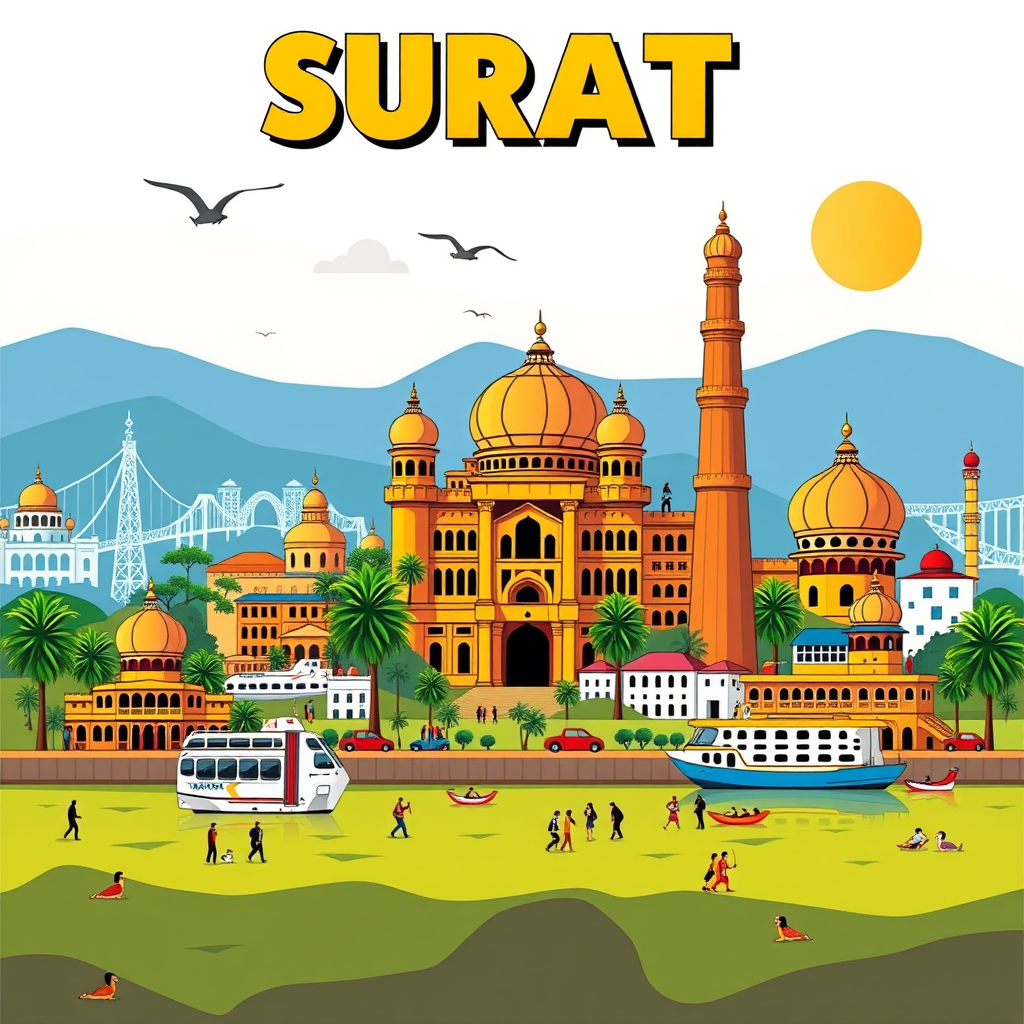

In [ ]:
# Test it
image = artist("Surat")
if image:
    display(image)

In [76]:
def talker(message):
    """Text-to-speech using canopylabs/orpheus-v1-english via Groq"""
    try:
        import tempfile
        import wave
        import numpy as np
        import os
        
        # Create a temporary file
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp_file:
            speech_file_path = tmp_file.name
        
        # Generate speech
        response = groq_client.audio.speech.create(
            model="canopylabs/orpheus-v1-english",
            voice="autumn",
            response_format="wav",
            input=message,
        )
        
        # Write to file (correct method)
        response.write_to_file(speech_file_path)
        
        # Read the file and convert to numpy array for Gradio
        with wave.open(speech_file_path, 'rb') as wav_file:
            frames = wav_file.readframes(wav_file.getnframes())
            audio_array = np.frombuffer(frames, dtype=np.int16)
            sample_rate = wav_file.getframerate()
        
        # Clean up temp file
        os.unlink(speech_file_path)
        
        # Return as tuple (sample_rate, audio_array)
        return (sample_rate, audio_array)
        
    except Exception as e:
        print(f"TTS error: {e}")
        return None

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [77]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [78]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    
    response = groq_client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools,
        tool_choice="auto",
        temperature=1,
        max_completion_tokens=1024,
        top_p=1
    )
    
    cities = []
    image = None

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        
        response = groq_client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
            tool_choice="auto",
            temperature=1,
            max_completion_tokens=1024,
            top_p=1
        )

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(label="Response", autoplay=True, type="numpy")
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True)

/tmp/ipykernel_4402/4202083243.py:10: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=500, type="messages")


* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


gio: http://127.0.0.1:7871/: Operation not supported


DATABASE TOOL CALLED: Getting price for Surat
 Generating image for Surat...
 Image generated! Credits - Remaining: 95, Consumed: 1


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>